Parallel Agents [Step 18 - Fan-Out/Fan-In Execution]

> **MLCourse - Agentic AI - LangGraph**

Parallel execution lets you run multiple agents simultaneously and aggregate
their results. LangGraph's `Send` API enables fan-out (dispatching work to
multiple nodes in parallel) and fan-in (collecting results into a single
state). This notebook builds a graph that runs three research agents in
parallel and merges their findings.

### What you will learn

1. Using `Send` to fan out work to parallel node instances.
2. Collecting parallel results with a reducer function.
3. Building a fan-out/fan-in graph pattern.
4. Visualizing parallel execution flow.

### Key takeaways

- `Send` dispatches copies of a node with different inputs.
- Reducer functions (via `Annotated`) merge parallel outputs automatically.
- Parallelism reduces total latency to the slowest agent, not the sum.

In [1]:
# --- Setup: imports, environment ---------------------------------------------

import os                           # env access
from dotenv import load_dotenv      # .env loading

load_dotenv(override=False)         # load without overriding

from typing import Annotated, TypedDict  # typed state
from operator import add             # reducer for merging parallel results
from langgraph.graph import StateGraph, END  # graph primitives
from langgraph.types import Send     # for fan-out to parallel nodes
from langchain_ollama import ChatOllama  # local LLM
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage  # messages

In [2]:
# --- Model guard: check Ollama -----------------------------------------------

try:                                        # connectivity test
    _test = ChatOllama(model="llama3.1:8b", temperature=0)
    _test.invoke("ping")
    LLM_AVAILABLE = True
    print("Ollama reachable -- full parallel pipeline will run")
except Exception as exc:
    LLM_AVAILABLE = False
    print("Ollama not reachable:", exc)

Ollama reachable -- full parallel pipeline will run


In [3]:
# --- Define parallel state: uses a list reducer for merging results -----------

class ParallelState(TypedDict):
    """State with a reducer that merges parallel agent outputs."""
    topic: str                            # the research topic
    # Annotated[list, add] means new values are APPENDED (not replaced)
    results: Annotated[list, add]         # merged results from parallel agents

In [4]:
# --- Define three specialized research agents --------------------------------

def tech_researcher(state: ParallelState) -> dict:
    """Technical researcher: finds technical details about the topic."""
    topic = state["topic"]                # get the topic from state
    print("[tech_researcher] researching:", topic[:40])

    if LLM_AVAILABLE:                     # use LLM for real research
        llm = ChatOllama(model="llama3.1:8b", temperature=0)
        response = llm.invoke([
            SystemMessage(content="You are a technical researcher. "
                         "Provide 2-3 technical bullet points."),
            HumanMessage(content="Research the technical aspects of: %s" % topic),
        ])
        result = "[Technical] %s" % response.content
    else:                                 # simulated response
        result = "[Technical] %s: Uses distributed architecture, supports 10K TPS" % topic

    print("[tech_researcher] done")
    return {"results": [result]}          # list wraps for the reducer

def market_researcher(state: ParallelState) -> dict:
    """Market researcher: finds market/business insights."""
    topic = state["topic"]
    print("[market_researcher] researching:", topic[:40])

    if LLM_AVAILABLE:
        llm = ChatOllama(model="llama3.1:8b", temperature=0)
        response = llm.invoke([
            SystemMessage(content="You are a market researcher. "
                         "Provide 2-3 market/business bullet points."),
            HumanMessage(content="Research the market aspects of: %s" % topic),
        ])
        result = "[Market] %s" % response.content
    else:
        result = "[Market] %s: Growing at 35%% CAGR, $50B market by 2027" % topic

    print("[market_researcher] done")
    return {"results": [result]}

def trend_researcher(state: ParallelState) -> dict:
    """Trend researcher: finds emerging trends and future outlook."""
    topic = state["topic"]
    print("[trend_researcher] researching:", topic[:40])

    if LLM_AVAILABLE:
        llm = ChatOllama(model="llama3.1:8b", temperature=0)
        response = llm.invoke([
            SystemMessage(content="You are a trend researcher. "
                         "Provide 2-3 emerging trend bullet points."),
            HumanMessage(content="Research trends for: %s" % topic),
        ])
        result = "[Trend] %s" % response.content
    else:
        result = "[Trend] %s: Multi-agent systems becoming mainstream in 2025" % topic

    print("[trend_researcher] done")
    return {"results": [result]}

In [5]:
# --- Aggregator node: combines parallel results into a summary ---------------

def aggregator(state: ParallelState) -> dict:
    """Aggregator: combines all parallel research into a final report."""
    all_results = state["results"]        # get all merged results
    print("[aggregator] combining %d research streams" % len(all_results))

    if LLM_AVAILABLE:                     # use LLM to synthesize
        llm = ChatOllama(model="llama3.1:8b", temperature=0)
        combined_text = "\n".join(all_results)  # join all results
        response = llm.invoke([
            SystemMessage(content="You are a research synthesizer. "
                         "Combine the following research into a brief 3-sentence summary."),
            HumanMessage(content=combined_text),
        ])
        summary = response.content
    else:                                 # simple concatenation
        summary = "Combined findings: " + "; ".join(
            r.split(":", 1)[-1].strip() for r in all_results
        ) if all_results else "No results"

    print("[aggregator] summary:", summary[:80])
    return {"results": ["[Summary] %s" % summary]}

In [6]:
# --- Fan-out function: decides which parallel nodes to dispatch ---------------

def fan_out_research(state: ParallelState) -> list:
    """Return a list of Send objects to dispatch parallel research tasks."""
    # Each Send creates an independent copy of the target node with its own input
    return [
        Send("tech_researcher", {"topic": state["topic"]}),     # parallel track 1
        Send("market_researcher", {"topic": state["topic"]}),   # parallel track 2
        Send("trend_researcher", {"topic": state["topic"]}),    # parallel track 3
    ]

In [7]:
# --- Build the parallel graph ------------------------------------------------

builder = StateGraph(ParallelState)

# Register all nodes
builder.add_node("tech_researcher", tech_researcher)
builder.add_node("market_researcher", market_researcher)
builder.add_node("trend_researcher", trend_researcher)
builder.add_node("aggregator", aggregator)

# Dispatcher node: triggers fan-out (virtual entry)
def dispatcher(state: ParallelState) -> dict:
    """Dispatcher node: triggers parallel fan-out."""
    print("[dispatcher] sending research tasks in parallel")
    return {}                             # no state change

builder.add_node("dispatcher", dispatcher)

# Wire the graph
builder.set_entry_point("dispatcher")
builder.add_conditional_edges("dispatcher", fan_out_research)  # fan out
# All parallel researchers connect to aggregator
builder.add_edge("tech_researcher", "aggregator")
builder.add_edge("market_researcher", "aggregator")
builder.add_edge("trend_researcher", "aggregator")
# Aggregator goes to END
builder.add_edge("aggregator", END)

graph = builder.compile()

print("Parallel graph compiled:")
print("  dispatcher -> [tech, market, trend] -> aggregator -> END")

Parallel graph compiled:
  dispatcher -> [tech, market, trend] -> aggregator -> END


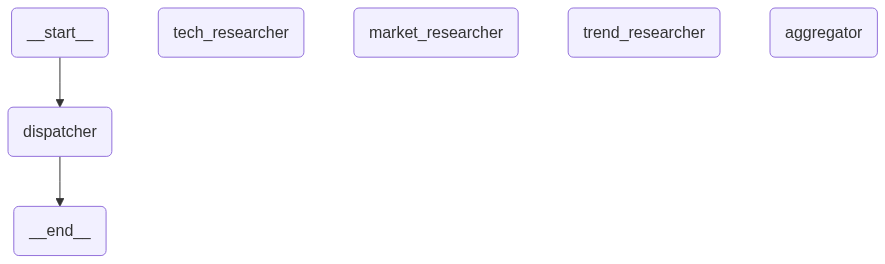

In [8]:
# --- Visualize the parallel graph --------------------------------------------

from IPython.display import Image, display

try:                                        # wrap in try/except for offline
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Visualization unavailable:", exc)
    print("Nodes:", list(builder.nodes.keys()))

In [9]:
# --- Run the parallel pipeline -----------------------------------------------

print("=== Parallel research execution ===")
print()

initial = {"topic": "LangGraph multi-agent systems", "results": []}

for step in graph.stream(initial):
    for node_name, output in step.items():
        if output is None:                 # dispatcher returns empty dict -> None
            print("[%s] dispatched (no output)" % node_name)
            continue
        results = output.get("results", [])
        if results:
            for r in results:
                print("[%s] %s" % (node_name, r[:80]))
        else:
            print("[%s] step completed" % node_name)

print()

=== Parallel research execution ===

[dispatcher] sending research tasks in parallel
[dispatcher] dispatched (no output)
[tech_researcher] researching: LangGraph multi-agent systems
[market_researcher] researching: LangGraph multi-agent systems
[trend_researcher] researching: LangGraph multi-agent systems


[trend_researcher] done
[trend_researcher] [Trend] Here are 3 emerging trend bullet points related to LangGraph multi-agent


[tech_researcher] done
[tech_researcher] [Technical] Here are three technical bullet points on LangGraph multi-agent syst


[market_researcher] done
[market_researcher] [Market] Here are 3 market-related bullet points for LangGraph multi-agent syste
[aggregator] combining 3 research streams


[aggregator] summary: Here is a 3-sentence summary combining the technical, market-related, and trend 
[aggregator] [Summary] Here is a 3-sentence summary combining the technical, market-related, 



In [10]:
# --- Show the reducer in action: results accumulate across parallel nodes ----

print("=== Reducer demonstration ===")
print()

# Run again and inspect the accumulated results
final = graph.invoke({"topic": "AI agent frameworks", "results": []})

print("Final results count:", len(final["results"]))
for i, r in enumerate(final["results"]):
    print("  result[%d]: %s" % (i, r[:70]))

print()
print("NOTEBOOK COMPLETE: parallel agents with fan-out/fan-in demonstrated")

=== Reducer demonstration ===

[dispatcher] sending research tasks in parallel
[tech_researcher] researching: AI agent frameworks
[market_researcher] researching: AI agent frameworks
[trend_researcher] researching: AI agent frameworks


[market_researcher] done


[tech_researcher] done


[trend_researcher] done
[aggregator] combining 3 research streams


[aggregator] summary: Here is a 3-sentence summary combining the technical, market, and trend bullet p
Final results count: 4
  result[0]: [Technical] Here are three technical bullet points on AI Agent Framewo
  result[1]: [Market] Here are 3 market/business bullet points related to AI Agent 
  result[2]: [Trend] Here are 3 emerging trend bullet points in the field of AI Age
  result[3]: [Summary] Here is a 3-sentence summary combining the technical, market

NOTEBOOK COMPLETE: parallel agents with fan-out/fan-in demonstrated
